# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Felix Benaya Prima]
- **Email:** [cdcc248d6y0834@student.devacademy.id]
- **ID Dicoding:** [CDCC248D6Y0834]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap jumlah total penyewaan sepeda harian selama tahun 2011–2012?
- **Pertanyaan 2:** Pada jam berapa saja terjadi puncak penyewaan sepeda dalam sehari, dan apakah pola tersebut berbeda antara hari kerja (workingday) dan hari libur selama tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

### Mengimpor seluruh library Python yang dibutuhkan dalam proses analisis data, visualisasi, dan pengolahan dataset.





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

## Data Wrangling

### Gathering Data


Pada tahap ini, kedua dataset dimuat ke dalam DataFrame:
- `day.csv`
- `hour.csv`

 File dibaca menggunakan `pd.read_csv()` dan diperiksa dimensinya untuk memastikan data berhasil dimuat dengan benar.

#### Load df ...

In [2]:
# Load dataset
df_day = pd.read_csv("day.csv")
df_hour = pd.read_csv("hour.csv")

print("Shape day.csv:", df_day.shape)
print("Shape hour.csv:", df_hour.shape)
print("\n--- Preview day.csv ---")
df_day.head()

Shape day.csv: (731, 16)
Shape hour.csv: (17379, 17)

--- Preview day.csv ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset terdiri dari dua tabel utama: data harian (day.csv) sebanyak 731 baris dan data per jam (hour.csv) sebanyak 17.379 baris.

- Keduanya memiliki struktur kolom yang identik terkait variabel cuaca, musim, dan tanggal, sehingga memudahkan proses analisis silang antar waktu.

### Assessing Data

Pada tahap ini, dilakukan penilaian kualitas data untuk mengidentifikasi permasalahan yang perlu ditangani sebelum analisis dilakukan.




In [3]:
print("=== INFO day.csv ===")
print(df_day.info())
print("\n=== MISSING VALUES day.csv ===")
print(df_day.isnull().sum())
print("\n=== DUPLICATE ROWS day.csv ===")
print("Jumlah duplikat:", df_day.duplicated().sum())
print("\n=== STATISTIK DESKRIPTIF day.csv ===")
df_day.describe()

=== INFO day.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

=== MISSING VALUES day.csv ===
instant       0
dteday        0
sea

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [4]:
print("=== INFO hour.csv ===")
print(df_hour.info())
print("\n=== MISSING VALUES hour.csv ===")
print(df_hour.isnull().sum())
print("\n=== DUPLICATE ROWS hour.csv ===")
print("Jumlah duplikat:", df_hour.duplicated().sum())
print("\n=== STATISTIK DESKRIPTIF hour.csv ===")
df_hour.describe()

=== INFO hour.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

=== MISSING VALUES ho

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [5]:
# Cek nilai unik kolom kategorikal
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

print("=== NILAI UNIK KOLOM KATEGORIKAL (day.csv) ===")
for col in cat_cols:
    print(f"{col}: {sorted(df_day[col].unique())}")

print("\n=== NILAI UNIK KOLOM KATEGORIKAL (hour.csv) ===")
for col in cat_cols + ['hr']:
    print(f"{col}: {sorted(df_hour[col].unique())}")

=== NILAI UNIK KOLOM KATEGORIKAL (day.csv) ===
season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr: [np.int64(0), np.int64(1)]
mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
holiday: [np.int64(0), np.int64(1)]
weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday: [np.int64(0), np.int64(1)]
weathersit: [np.int64(1), np.int64(2), np.int64(3)]

=== NILAI UNIK KOLOM KATEGORIKAL (hour.csv) ===
season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr: [np.int64(0), np.int64(1)]
mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
holiday: [np.int64(0), np.int64(1)]
weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday: [np.int64(0

In [6]:
print("Tipe data kolom 'dteday' di day.csv :", df_day['dteday'].dtype)
print("Tipe data kolom 'dteday' di hour.csv:", df_hour['dteday'].dtype)

Tipe data kolom 'dteday' di day.csv : object
Tipe data kolom 'dteday' di hour.csv: object


#### Identifying ... problem

**Steps to Take:**
- **Invalid data type:** Kolom `dteday` pada kedua dataset bertipe `object`, seharusnya bertipe `datetime` agar dapat digunakan dalam analisis berbasis waktu.

- **Inaccurate value:** Kolom kategorikal seperti `season` dan `weathersit` masih berupa angka integer tanpa label yang bermakna, sehingga sulit diinterpretasi secara langsung.


**Insight:** (Opsional)
- Kelebihan: Tidak ditemukan missing value (Null) maupun baris duplikat pada kedua dataset. Ini menandakan data sudah cukup solid dari sisi kelengkapan.

- Kekurangan (Masalah Tipe Data): Kolom tanggal (dteday) masih terbaca sebagai tipe object (string), bukan tipe datetime.


### Cleaning Data

Berdasarkan permasalahan yang ditemukan pada tahap Assessing Data, dilakukan dua langkah pembersihan:

1. **Konversi tipe data:** Kolom `dteday` dikonversi dari `object` menjadi `datetime` menggunakan `pd.to_datetime()`.
2. **Pelabelan kolom kategorikal:** Kolom `season`, `weathersit`, `yr`, dan `workingday` ditambahkan kolom label baru dengan mapping nilai integer ke nama kategori yang bermakna.

Setelah cleaning, data siap digunakan untuk tahap eksplorasi dan analisis lebih lanjut.

In [7]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

print("Tipe data setelah cleaning:")
print("day.csv  - dteday:", df_day['dteday'].dtype)
print("hour.csv - dteday:", df_hour['dteday'].dtype)

Tipe data setelah cleaning:
day.csv  - dteday: datetime64[ns]
hour.csv - dteday: datetime64[ns]


In [8]:
# Mapping label
season_map     = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map    = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
yr_map         = {0: '2011', 1: '2012'}
workingday_map = {0: 'Non-Working Day', 1: 'Working Day'}

for df in [df_day, df_hour]:
    df['season_label']     = df['season'].map(season_map)
    df['weathersit_label'] = df['weathersit'].map(weather_map)
    df['yr_label']         = df['yr'].map(yr_map)
    df['workingday_label'] = df['workingday'].map(workingday_map)

print("Kolom baru berhasil ditambahkan.")
print(df_day[['season', 'season_label', 'weathersit', 'weathersit_label']].head())

Kolom baru berhasil ditambahkan.
   season season_label  weathersit weathersit_label
0       1       Spring           2             Mist
1       1       Spring           2             Mist
2       1       Spring           1            Clear
3       1       Spring           1            Clear
4       1       Spring           1            Clear


In [9]:
df_day.to_csv("main_data.csv", index=False)

#### Fixing ... problem

**Insight:** (Opsional)
- Transformasi data telah berhasil dilakukan. Kolom dteday kini berformat datetime64[ns], sehingga operasi deret waktu (time-series) dapat dilakukan jika diperlukan.

- Penambahan kolom baru berakhiran _label (seperti season_label dan weathersit_label) membuat DataFrame kini lebih deskriptif dan siap dipakai (ready-to-use) untuk proses pembuatan grafik yang mudah dibaca oleh non-teknikal stakeholder.

## Exploratory Data Analysis (EDA)

Pada tahap ini, dilakukan eksplorasi data untuk menjawab kedua pertanyaan bisnis yang telah dirumuskan.

Eksplorasi dilakukan dengan melakukan grouping dan agregasi pada variabel-variabel yang relevan, yaitu musim, kondisi cuaca, jam, dan tipe hari, untuk melihat pola distribusi dan rata-rata penyewaan sepeda.

### Pertanyaan 1: EDA (Pengaruh Cuaca & Musim)



In [10]:
# Rata-rata penyewaan berdasarkan musim
season_avg = df_day.groupby('season_label')['cnt'].mean().reset_index()
season_avg.columns = ['Musim', 'Rata-rata Penyewaan']
season_avg = season_avg.sort_values('Rata-rata Penyewaan', ascending=False)
print("=== Rata-rata Penyewaan per Musim ===")
print(season_avg)

# Rata-rata penyewaan berdasarkan kondisi cuaca
weather_avg = df_day.groupby('weathersit_label')['cnt'].mean().reset_index()
weather_avg.columns = ['Cuaca', 'Rata-rata Penyewaan']
weather_avg = weather_avg.sort_values('Rata-rata Penyewaan', ascending=False)
print("\n=== Rata-rata Penyewaan per Kondisi Cuaca ===")
print(weather_avg)

=== Rata-rata Penyewaan per Musim ===
    Musim  Rata-rata Penyewaan
0    Fall          5644.303191
2  Summer          4992.331522
3  Winter          4728.162921
1  Spring          2604.132597

=== Rata-rata Penyewaan per Kondisi Cuaca ===
             Cuaca  Rata-rata Penyewaan
0            Clear          4876.786177
2             Mist          4035.862348
1  Light Snow/Rain          1803.285714


### Pertanyaan 2: EDA (Pola Per Jam)

In [11]:
# Rata-rata penyewaan per jam
hour_avg = df_hour.groupby('hr')['cnt'].mean().reset_index()
hour_avg.columns = ['Jam', 'Rata-rata Penyewaan']
print("=== Rata-rata Penyewaan per Jam ===")
print(hour_avg)

# Rata-rata per jam berdasarkan hari kerja vs libur
hour_workday = df_hour.groupby(['hr', 'workingday_label'])['cnt'].mean().reset_index()
hour_workday.columns = ['Jam', 'Tipe Hari', 'Rata-rata Penyewaan']
print("\n=== Preview Penyewaan per Jam & Tipe Hari ===")
print(hour_workday.head(10))

=== Rata-rata Penyewaan per Jam ===
    Jam  Rata-rata Penyewaan
0     0            53.898072
1     1            33.375691
2     2            22.869930
3     3            11.727403
4     4             6.352941
5     5            19.889819
6     6            76.044138
7     7           212.064649
8     8           359.011004
9     9           219.309491
10   10           173.668501
11   11           208.143054
12   12           253.315934
13   13           253.661180
14   14           240.949246
15   15           251.233196
16   16           311.983562
17   17           461.452055
18   18           425.510989
19   19           311.523352
20   20           226.030220
21   21           172.314560
22   22           131.335165
23   23            87.831044

=== Preview Penyewaan per Jam & Tipe Hari ===
   Jam        Tipe Hari  Rata-rata Penyewaan
0    0  Non-Working Day            90.800000
1    0      Working Day            36.786290
2    1  Non-Working Day            69.508696
3    1      

**Insight:** (Opsional)
- Tabel per jam mengungkap lonjakan tajam mulai pukul 07:00 pagi dan 16:00 sore, mengindikasikan fungsi dominan sepeda ini sebagai alat transportasi pekerja (commuter).

- Dari data, terlihat tren awal, musim Fall memimpin dengan lebih dari 5.600 rata-rata penyewaan per hari,

## Visualization & Explanatory Analysis

1.   Visualisasi dibuat untuk memperkuat temuan dari tahap EDA dan menjawab secara visual kedua pertanyaan bisnis yang telah dirumuskan.

2.   Setiap pertanyaan bisnis dijawab oleh minimal satu visualisasi yang menerapkan prinsip kejelasan, akurasi, dan kemudahan interpretasi.




## Explanatory Analysis

## Visualization

### Pertanyaan 1: Pengaruh Musim & Cuaca

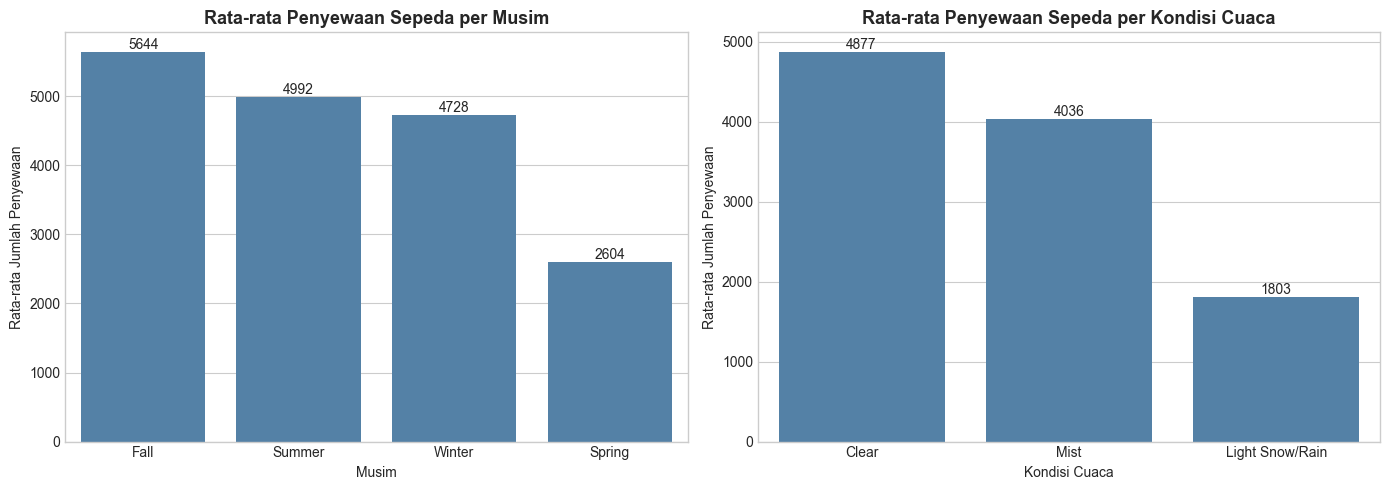

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Musim (Gunakan 1 warna seragam)
order_season = season_avg.sort_values('Rata-rata Penyewaan', ascending=False)['Musim']
sns.barplot(data=season_avg, x='Musim', y='Rata-rata Penyewaan',
            order=order_season, ax=axes[0], color='steelblue') # <--- Perubahan di sini
axes[0].set_title('Rata-rata Penyewaan Sepeda per Musim', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.0f}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Plot 2: Cuaca (Gunakan 1 warna seragam)
order_weather = weather_avg.sort_values('Rata-rata Penyewaan', ascending=False)['Cuaca']
sns.barplot(data=weather_avg, x='Cuaca', y='Rata-rata Penyewaan',
            order=order_weather, ax=axes[1], color='steelblue') # <--- Perubahan di sini
axes[1].set_title('Rata-rata Penyewaan Sepeda per Kondisi Cuaca', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan')
for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.0f}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Pola Penyewaan per Jam

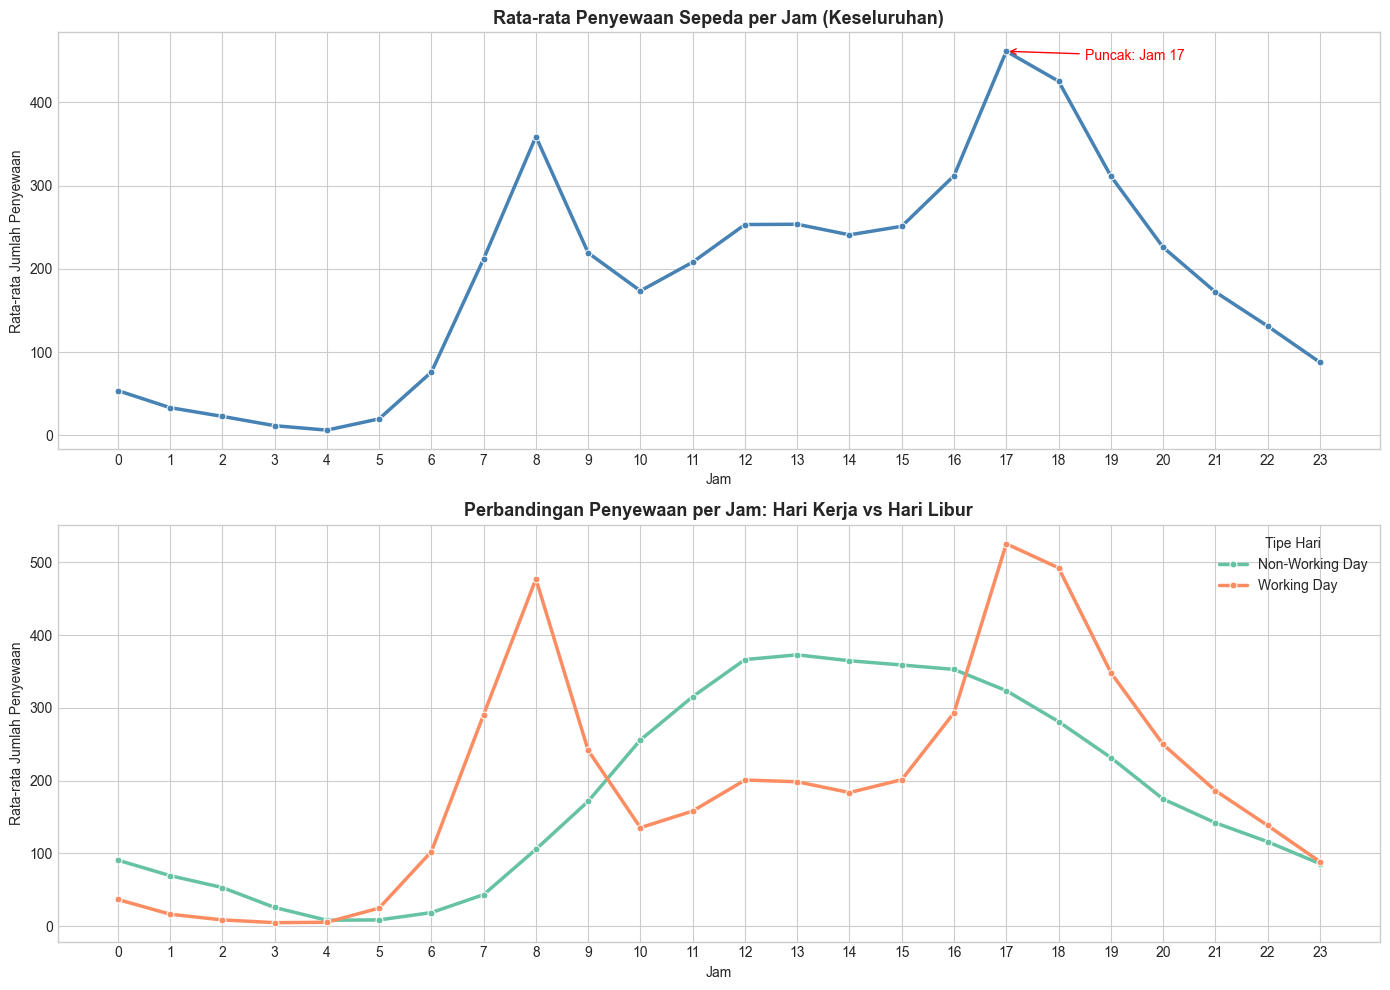

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Rata-rata per jam keseluruhan
sns.lineplot(data=hour_avg, x='Jam', y='Rata-rata Penyewaan',
             ax=axes[0], color='steelblue', linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Rata-rata Penyewaan Sepeda per Jam (Keseluruhan)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan')
axes[0].set_xticks(range(0, 24))

# Tandai puncak
peak_hour = hour_avg.loc[hour_avg['Rata-rata Penyewaan'].idxmax()]
axes[0].annotate(f"Puncak: Jam {int(peak_hour['Jam'])}",
                 xy=(peak_hour['Jam'], peak_hour['Rata-rata Penyewaan']),
                 xytext=(peak_hour['Jam'] + 1.5, peak_hour['Rata-rata Penyewaan'] - 10),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Plot 2: Per jam berdasarkan tipe hari
sns.lineplot(data=hour_workday, x='Jam', y='Rata-rata Penyewaan',
             hue='Tipe Hari', ax=axes[1], linewidth=2.5, marker='o', markersize=5)
axes[1].set_title('Perbandingan Penyewaan per Jam: Hari Kerja vs Hari Libur', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan')
axes[1].set_xticks(range(0, 24))
axes[1].legend(title='Tipe Hari')

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan2.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** (Opsional)
- Grafik Musim: Secara visual, bar chart mempertegas bahwa performa terburuk terjadi di musim semi (Spring). Ini mungkin karena transisi dari musim dingin yang masih membawa suhu rendah.

- Bimodal Pattern: Pada hari kerja (Working Day), grafik garis membentuk pola "Bimodal" (dua puncak) yang sangat ekstrem di pukul 08:00 dan 17:00. Ini konfirmasi kuat bahwa penyewa mayoritas adalah pekerja kantoran.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation



- **Conclusion pertanyaan 1:**
  - **Musim:** Musim Gugur (*Fall*) mencatat rata-rata penyewaan tertinggi yaitu sebesar 5.644 penyewaan per hari. Diikuti oleh musim *Summer* (4.992) dan *Winter* (4.728). Sebaliknya, penyewaan paling sepi terjadi pada musim *Spring* dengan rata-rata hanya 2.604 penyewaan per hari (turun lebih dari 50% dibandingkan musim *Fall*).
  - **Cuaca:** Kondisi cuaca cerah (*Clear/Partly Cloudy*) menghasilkan rata-rata penyewaan tertinggi sebesar 4.877 penyewaan per hari. Kondisi berkabut (*Mist*) sedikit menurunkan penyewaan ke angka 4.036. Namun, cuaca buruk seperti hujan/salju ringan (*Light Snow/Rain*) menurunkan penyewaan secara drastis hingga menyentuh angka 1.803 penyewaan per hari (anjlok sekitar 63% dibanding hari cerah).

- **Conclusion pertanyaan 2:**
  - **Secara Keseluruhan:** Puncak penyewaan sepeda secara umum terjadi pada pukul 17:00 (rata-rata 461 penyewaan) dan pukul 08:00 pagi (rata-rata 359 penyewaan).
  - **Hari Kerja (Working Day):** Pola bimodal (dua puncak) sangat dominan karena dipengaruhi oleh mobilitas pekerja (*commuter*). Lonjakan tajam terlihat pada jam berangkat kerja pukul 08:00 (mendekati 500 penyewaan) dan jam pulang kerja pukul 17:00 (mencapai lebih dari 500 penyewaan).
  - **Hari Libur (Non-Working Day):** Pola penyewaan berubah menjadi *unimodal* (merata di tengah hari). Permintaan mulai naik pada pukul 10:00 dan bertahan tinggi hingga pukul 15:00 dengan rata-rata di kisaran 360-380 penyewaan per jam, menunjukkan transisi fungsi sepeda untuk aktivitas rekreasi santai.

**Rekomendasi Action Item:**
- Tingkatkan ketersediaan armada sepeda pada jam sibuk (07.00-09.00 & 16.00-19.00)
   khususnya di hari kerja untuk memenuhi demand commuter.
- Buat program promosi atau diskon khusus di musim Spring dan saat cuaca buruk
   untuk mendorong penyewaan di periode permintaan rendah.